<a href="https://colab.research.google.com/github/BernardoBremer/Inteligencia-Computacional-Cetys-/blob/main/FeedForward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Neural Networks (implementacion con pytorch)

usando el notebook de introduction to neural networks como base, ahora se realizara utilizando pytorch, torch, nn.linear y nn.ReLU, en este ejercicio se entrenan 3 networks distintas con arquitectura variada  como learning rate, batch size, epochs y al final se evaluara el mejor modelo en el conjusto de test

In [30]:
import numpy as np
import gzip
import urllib.request
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## MNIST dataset (carga como dataset de pytorch)

los arrays de numpy ya estan cargados y normalizados en el notebook original, simplemente los convertimos a tensores y los envolvemos en Tensordataset

In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full   = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(train_full, [50000, 10000])

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 50000 | Val: 10000 | Test: 10000


### Definición de las 3 Redes Neuronales

Se definen 3 arquitecturas diferentes usando únicamente nn.Linear y nn.ReLU:

| Modelo | Arquitectura | LR | Batch Size | Épocas |
|--------|-------------|-----|------------|--------|
| Modelo A | 784 → 128 → 10 | 0.001 | 64 | 15 |
| Modelo B | 784 → 256 → 128 → 10 | 0.0005 | 128 | 20 |
| Modelo C | 784 → 512 → 256 → 128 → 10 | 0.0003 | 32 | 15 |

In [32]:
class ModeloA(nn.Module):
    def __init__(self):
        super(ModeloA, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)


class ModeloB(nn.Module):
    def __init__(self):
        super(ModeloB, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)


class ModeloC(nn.Module):
    def __init__(self):
        super(ModeloC, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)

#Funcion de loss y loop entrenamiento



In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def entrenar_modelo(model, train_dataset, val_dataset, epochs, batch_size, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = total_loss / total
        train_acc = correct / total

        model.eval()
        val_loss_total, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history


def evaluar_en_test(model, test_dataset):
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
    criterion = nn.CrossEntropyLoss()
    test_loss_total, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss_total += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return test_loss_total / total, correct / total

#Entrenamiento modelo A

In [34]:
modelo_a = ModeloA()
hist_a = entrenar_modelo(modelo_a, train_dataset, val_dataset,
                         epochs=15, batch_size=64, learning_rate=0.001)

Epoch 1/15: 100%|██████████| 782/782 [00:17<00:00, 44.33it/s, loss=0.0613]


  Train Loss: 0.2819 | Train Acc: 0.9179 | Val Loss: 0.1656 | Val Acc: 0.9530


Epoch 2/15: 100%|██████████| 782/782 [00:18<00:00, 43.05it/s, loss=0.2433]


  Train Loss: 0.1242 | Train Acc: 0.9621 | Val Loss: 0.1232 | Val Acc: 0.9614


Epoch 3/15: 100%|██████████| 782/782 [00:17<00:00, 44.74it/s, loss=0.1179]


...

  Train Loss: 0.0142 | Train Acc: 0.9953 | Val Loss: 0.1026 | Val Acc: 0.9734


Epoch 14/15: 100%|██████████| 782/782 [00:17<00:00, 43.53it/s, loss=0.0034]


  Train Loss: 0.0138 | Train Acc: 0.9953 | Val Loss: 0.0975 | Val Acc: 0.9764


Epoch 15/15: 100%|██████████| 782/782 [00:17<00:00, 44.52it/s, loss=0.0001]


  Train Loss: 0.0119 | Train Acc: 0.9961 | Val Loss: 0.0975 | Val Acc: 0.9769


#Entrenamiento modelo B

In [35]:
modelo_b = ModeloB()
hist_b = entrenar_modelo(modelo_b, train_dataset, val_dataset,
                         epochs=20, batch_size=128, learning_rate=0.0005)

Epoch 1/20: 100%|██████████| 391/391 [00:15<00:00, 24.92it/s, loss=0.2192]


  Train Loss: 0.3703 | Train Acc: 0.8973 | Val Loss: 0.1821 | Val Acc: 0.9445


Epoch 2/20: 100%|██████████| 391/391 [00:16<00:00, 24.33it/s, loss=0.2070]


  Train Loss: 0.1489 | Train Acc: 0.9563 | Val Loss: 0.1378 | Val Acc: 0.9566


Epoch 3/20: 100%|██████████| 391/391 [00:15<00:00, 24.95it/s, loss=0.2845]


...

  Train Loss: 0.0079 | Train Acc: 0.9974 | Val Loss: 0.0947 | Val Acc: 0.9784


Epoch 19/20: 100%|██████████| 391/391 [00:15<00:00, 24.94it/s, loss=0.0010]


  Train Loss: 0.0063 | Train Acc: 0.9980 | Val Loss: 0.0842 | Val Acc: 0.9800


Epoch 20/20: 100%|██████████| 391/391 [00:15<00:00, 24.91it/s, loss=0.0130]


  Train Loss: 0.0053 | Train Acc: 0.9983 | Val Loss: 0.1138 | Val Acc: 0.9742


#Entrenamineto modelo C

In [36]:
modelo_c = ModeloC()
hist_c = entrenar_modelo(modelo_c, train_dataset, val_dataset,
                         epochs=15, batch_size=32, learning_rate=0.0003)

Epoch 1/15: 100%|██████████| 1563/1563 [00:31<00:00, 50.30it/s, loss=0.0505]


  Train Loss: 0.2709 | Train Acc: 0.9182 | Val Loss: 0.1249 | Val Acc: 0.9624


Epoch 2/15: 100%|██████████| 1563/1563 [00:30<00:00, 50.47it/s, loss=0.0373]


  Train Loss: 0.1027 | Train Acc: 0.9683 | Val Loss: 0.0862 | Val Acc: 0.9727


Epoch 3/15: 100%|██████████| 1563/1563 [00:31<00:00, 49.39it/s, loss=0.0673]


...

  Train Loss: 0.0131 | Train Acc: 0.9956 | Val Loss: 0.0873 | Val Acc: 0.9792


Epoch 14/15: 100%|██████████| 1563/1563 [00:31<00:00, 49.50it/s, loss=0.0001]


  Train Loss: 0.0121 | Train Acc: 0.9959 | Val Loss: 0.0959 | Val Acc: 0.9781


Epoch 15/15: 100%|██████████| 1563/1563 [00:32<00:00, 48.71it/s, loss=0.0002]


  Train Loss: 0.0131 | Train Acc: 0.9962 | Val Loss: 0.0951 | Val Acc: 0.9779


#Comparacion de los 3 modelos

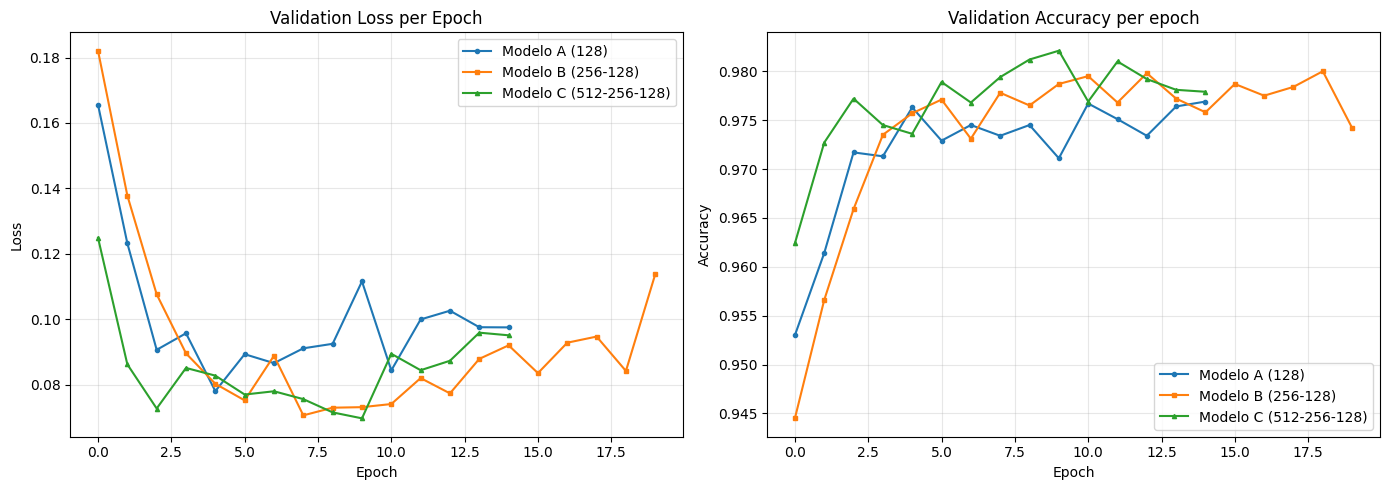

Model                       Val Loss    Val Acc
A (784-128-10)                0.0975     0.9769
B (784-256-128-10)            0.1138     0.9742
C (784-512-256-128-10)        0.0951     0.9779


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_a['val_loss'], label='Modelo A (128)', marker='o', markersize=3)
axes[0].plot(hist_b['val_loss'], label='Modelo B (256-128)', marker='s', markersize=3)
axes[0].plot(hist_c['val_loss'], label='Modelo C (512-256-128)', marker='^', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validation Loss per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_a['val_acc'], label='Modelo A (128)', marker='o', markersize=3)
axes[1].plot(hist_b['val_acc'], label='Modelo B (256-128)', marker='s', markersize=3)
axes[1].plot(hist_c['val_acc'], label='Modelo C (512-256-128)', marker='^', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy per epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"{'Model':<25} {'Val Loss':>10} {'Val Acc':>10}")
print(f"{'A (784-128-10)':<25} {hist_a['val_loss'][-1]:>10.4f} {hist_a['val_acc'][-1]:>10.4f}")
print(f"{'B (784-256-128-10)':<25} {hist_b['val_loss'][-1]:>10.4f} {hist_b['val_acc'][-1]:>10.4f}")
print(f"{'C (784-512-256-128-10)':<25} {hist_c['val_loss'][-1]:>10.4f} {hist_c['val_acc'][-1]:>10.4f}")


#Seleccion y evaluacion del mejor modelo en Test

Se selecciona el modelo con mejor accuracy en validación y se evalúa en el conjunto de test (loss y accuracy).

In [38]:
val_results = {
    'Modelo A': hist_a['val_acc'][-1],
    'Modelo B': hist_b['val_acc'][-1],
    'Modelo C': hist_c['val_acc'][-1],
}

best_name = max(val_results, key=val_results.get)
best_model = {'Modelo A': modelo_a, 'Modelo B': modelo_b, 'Modelo C': modelo_c}[best_name]

test_loss, test_acc = evaluar_en_test(best_model, test_dataset)

print(f"Mejor modelo en validation: {best_name} — Val Acc: {val_results[best_name]:.4f}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


Mejor modelo en validation: Modelo C — Val Acc: 0.9779
Test Loss:     0.1040
Test Accuracy: 0.9781 (97.81%)


#Conclusiones

se implemento correctamente 3 redes neuronales feedforward utilizando pytorch para el conjunto de MNIST, los tres modelos lograron un accuracy arriba de 97% en validation.

el modelo c resulto ser el mejor balance, aunque el modelo a es mas pequeno, convergio rapido y obutvo resultados competitivos. el modelo b a pesar de tener mas parametros mostro senales de overfitting, la val loss comenzo a subir mientras la train loss seguia bajando.